# MSCFE 690: Capstone Project
### Student Group: 11186

The notebook contains the development of a Bayesian Network (BN) model based on DYNOTEARS, and an example of how inferences can be used for utility optimization to estimate factor weight allocations.

This exercise is part of early idea & algorithm explorations, and represents an early proof-of-concept (PoC). This is NOT the final version of the workflow or the model.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib
import yfinance as yf
import pandas_datareader as web
from seaborn import heatmap
import causalnex

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,3)
import warnings
warnings.filterwarnings('ignore')

print(f"platform:\t\t{sys.platform}")
print(f"python version:\t\t{sys.version}")
print(f"pandas version:\t\t{pd.__version__}")
print(f"numpy version:\t\t{np.__version__}")
print(f"matplotlib version:\t{matplotlib.__version__}")
print(f"yfinance version:\t{yf.__version__}")
print(f"pd-datareader version:\t{web.__version__}")
print(f"causalnex version:\t{causalnex.__version__}")

platform:		darwin
python version:		3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
pandas version:		2.2.3
numpy version:		1.23.5
matplotlib version:	3.10.5
yfinance version:	0.2.65
pd-datareader version:	0.10.0
causalnex version:	0.12.1


---
### Changes made since M4 submission & following M5 peer review:

- Regime labels from EDA have been incorporated
- Code has been refactored & reusable functions were made
- Commments & docstrings have been added & expanded
- Corrected a calculation error in DBN parameter learning code in the previous version
- Model quality from a single train-test split was evaluated
- Portfolio optimization now utilizes ```cvxpy``` to incorporate constraints (total weights = 1, max weight per factor = 30 %). The optimization function also includes an adjustable risk-aversion coefficient.
- S&P 500 benchmark, equal-weight (1/N), and rolling MVO portfolios were added for comparisons
- Implemented walk-forward backtest with error handling for long only & long-short portfolios

---

Note: The DYNOTEARS model has been implemented in CausalNex library (https://github.com/mckinsey/causalnex/blob/develop/causalnex/structure/dynotears.py).

Note that it requires ```python_version <= 3.10```. This could be in conflict with the requirements for some other libraries we might want to use.

For more information on CausalNex, please refer to: https://github.com/mckinsey/causalnex/tree/develop and https://causalnex.readthedocs.io/en/latest/.

## Section 1 - Data Preparation

### 1.1. Data Processing

For more information on how the factor returns data were retrieved and processed, as well as an extensive EDA on them, please refer to: https://github.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/blob/main/notebooks/01_EDA_ETL.ipynb and https://github.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/blob/main/inputs/meta/etl_decisions.md.

In [2]:
# fetch data from previously processed csv by DS

csv_path = "../inputs/clean/osap_factor_for_dbn_with_regime.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    url = "https://raw.githubusercontent.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/main/inputs/clean/osap_factors_for_dbn_with_regime.csv"
    df = pd.read_csv(url)

# convert index to datetime format
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.index = df['date']
del df['date']

# convert factor returns to decimals
df.iloc[:,:-1]  = df.iloc[:,:-1] / 100
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 719 entries, 1964-02-28 to 2023-12-29
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BM               719 non-null    float64
 1   IdioVol3F        719 non-null    float64
 2   Investment       719 non-null    float64
 3   Mom12m           719 non-null    float64
 4   OperProf         719 non-null    float64
 5   Size             719 non-null    float64
 6   BM_lag1          719 non-null    float64
 7   IdioVol3F_lag1   719 non-null    float64
 8   Investment_lag1  719 non-null    float64
 9   Mom12m_lag1      719 non-null    float64
 10  OperProf_lag1    719 non-null    float64
 11  Size_lag1        719 non-null    float64
 12  regime           719 non-null    int64  
dtypes: float64(12), int64(1)
memory usage: 78.6 KB


In [3]:
# retrieve indices data from Yahoo Finance
start = df.index[0]
end = df.index[-1]

tick = ['^GSPC', '^RUT', 'DX-Y.NYB', '^IRX']
yfin_data = yf.download(tick,
                        start,
                        end,
                        auto_adjust=False,
                        progress=False)['Close']

# change variable names into something more intuitive
yfin_data = yfin_data.loc[:,tick]
yfin_data.columns.name = None
yfin_data.rename(columns = {
    '^GSPC': 'SP500',
    '^RUT': 'RSSL2K',
    'DX-Y.NYB': 'USDIDX',
    '^IRX': 'TBLL13WK',
    },
    inplace=True)

yfin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15252 entries, 1964-02-28 to 2023-12-28
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SP500     15062 non-null  float64
 1   RSSL2K    9148 non-null   float64
 2   USDIDX    13462 non-null  float64
 3   TBLL13WK  14976 non-null  float64
dtypes: float64(4)
memory usage: 595.8 KB


In [4]:
# fetch macroeconomic indicator data from FRED
datasets_fred = [
    'GDP',
    'UNRATE',
    'CPIAUCSL',
    'USEPUINDXD',
    'TRESEGUSM052N',
    'WTISPLC'
    ]

fred_data = pd.DataFrame()
for f in datasets_fred:
    fred_data[f] = web.DataReader(f,'fred',start,end)
fred_data.rename(columns = {
    'CPIAUCSL': 'INFLATION',
    'TRESEGUSM052N': 'GLDRSRV',
    'USEPUINDXD': 'POLICY',
    'WTISPLC': 'CRUDOIL'
    },
    inplace=True)
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 239 entries, 1964-04-01 to 2023-10-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GDP        239 non-null    float64
 1   UNRATE     239 non-null    float64
 2   INFLATION  239 non-null    float64
 3   POLICY     156 non-null    float64
 4   GLDRSRV    239 non-null    float64
 5   CRUDOIL    239 non-null    float64
dtypes: float64(6)
memory usage: 13.1 KB


### 1.2. Data Aggregation

In [5]:
# concatenate into 1 dataframe
df1 = pd.concat([df.iloc[:,:6], yfin_data, fred_data, df.iloc[:,-1]], axis=1, join='outer')

# transform factor returns into cumulative returns
for k in df1.columns[:6]:
    df1[k] = (1 + df1[k]).cumprod()

# forward fill using the last data to avoid look-ahead bias
df1 = df1.ffill()

# resample monthly & drop NaNs
df1 = df1.resample('ME').last()
df1 = df1.dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 436 entries, 1987-09-30 to 2023-12-31
Freq: ME
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          436 non-null    float64
 1   IdioVol3F   436 non-null    float64
 2   Investment  436 non-null    float64
 3   Mom12m      436 non-null    float64
 4   OperProf    436 non-null    float64
 5   Size        436 non-null    float64
 6   SP500       436 non-null    float64
 7   RSSL2K      436 non-null    float64
 8   USDIDX      436 non-null    float64
 9   TBLL13WK    436 non-null    float64
 10  GDP         436 non-null    float64
 11  UNRATE      436 non-null    float64
 12  INFLATION   436 non-null    float64
 13  POLICY      436 non-null    float64
 14  GLDRSRV     436 non-null    float64
 15  CRUDOIL     436 non-null    float64
 16  regime      436 non-null    float64
dtypes: float64(17)
memory usage: 61.3 KB


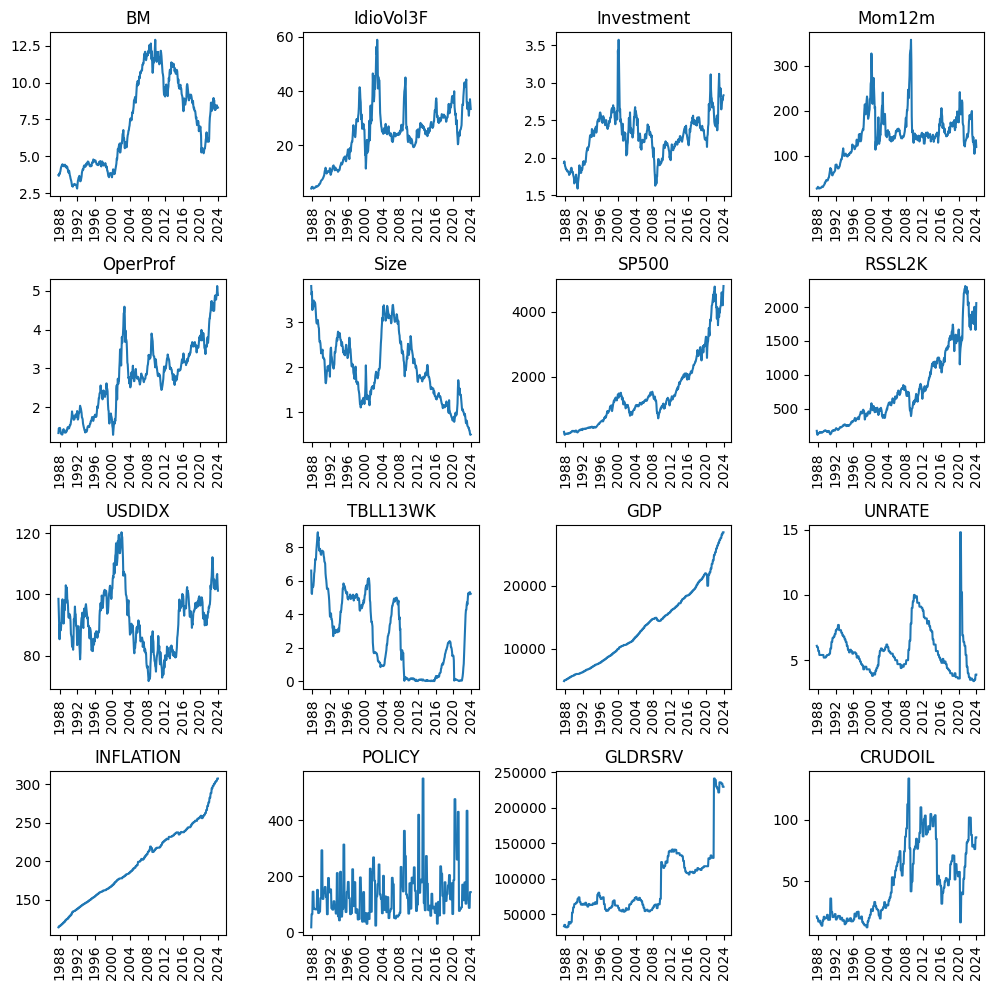

In [6]:
# quick visualization of the processed data
rows = 4
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10,10))
for r in range(rows):
    for c in range(cols):
        axs[r,c].plot(df1.iloc[:, cols*r+c])
        axs[r,c].set_title(df1.columns[cols*r+c])
        axs[r,c].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [7]:
df1.to_csv('../outputs/dynotears/data_clean_dynotears_poc.csv')

csv_path = "../outputs/dynotears/data_clean_dynotears_poc.csv"
if os.path.exists(csv_path):
    df1 = pd.read_csv(csv_path)
else:
    url = "https://raw.githubusercontent.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/main/outputs/dynotears/data_clean_dynotears_poc.csv"
    df1 = pd.read_csv(url)

# convert index to datetime format
df1['Unnamed: 0'] = pd.to_datetime(df1['Unnamed: 0'], format='%Y-%m-%d')
df1.index = df1['Unnamed: 0']
df1.index.name = None
del df1['Unnamed: 0']
df1.head()

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size,SP500,RSSL2K,USDIDX,TBLL13WK,GDP,UNRATE,INFLATION,POLICY,GLDRSRV,CRUDOIL,regime
1987-09-30,3.729619,4.104436,1.931423,26.450129,1.333317,3.802171,321.829987,170.809998,98.570000,6.61,4884.555,6.1,113.8,17.40,33249.337067,21.355,1.0
1987-10-31,3.674858,4.558925,1.950490,26.792436,1.457434,3.605628,251.789993,118.260002,93.650002,5.27,5007.994,6.0,115.0,64.37,35115.497391,19.848,1.0
1987-11-30,3.826004,4.500859,1.917082,26.976968,1.434539,3.672181,230.300003,111.699997,89.150002,5.21,5007.994,6.0,115.0,64.37,35115.497391,19.848,1.0
1987-12-31,3.779473,4.738117,1.884721,30.421728,1.445605,3.268938,247.080002,120.419998,85.419998,5.68,5007.994,6.0,115.0,64.37,35115.497391,19.848,1.0
1988-01-31,3.916253,4.622518,1.873622,28.050757,1.466801,3.399708,257.070007,125.239998,90.339996,5.64,5073.372,5.7,116.0,144.53,31886.416594,17.160,1.0


### 1.3. Data Discretization with Trend Scanning

This **trend scanning** method was taken from Lopez de Prado's book (Machine Learning for Asset Managers, pp. 67-72). The Python implementation below was modified from code adaptations by Endre Moen (https://github.com/emoen/Machine-Learning-for-Asset-Managers).

Basically, this method uses the t-statistics from rolling linear regressions to determine if a stretch of price or index level series is part of an up-trend or a down-trend. I've modified the code so that it can label sideways price movement too (i.e., no trend), so we'll end up with 3 labels or "states".

In [8]:
import statsmodels.api as sm

def tValLinR(close: np.ndarray) -> float:
    """
    Compute the t-statistic of the slope coefficient from an OLS regression
    of `close` values against time.

    Parameters
    ----------
    close : np.ndarray
        Array of values (e.g., prices) in the window.

    Returns
    -------
    float
        t-statistic of the slope coefficient.
    """
    if close.ndim > 1:
        close = close.ravel()

    n = close.shape[0]
    x = np.ones((n, 2))
    x[:, 1] = np.arange(n)
    ols = sm.OLS(close, x).fit()
    return float(ols.tvalues[1])


def getBinsFromTrend(
    molecule: pd.Index,
    close: pd.Series,
    span: tuple[int, int, int], # = (3, 20, 1),
    tval_clip: float = 30.0,
) -> pd.DataFrame:
    """
    Apply the trend-scanning method to generate labels.

    Parameters
    ----------
    molecule : pd.Index
        Subset of indices from `close` to evaluate.
    close : pd.Series
        Price or time series data.
    span : tuple[int, int, int], optional
        Range of window sizes to test (start, stop, step).
        Example: (3, 10, 1) tests windows of size 3..9.
    tval_clip : float, optional
        Maximum absolute value to clip t-statistics at.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - t1: Start time of chosen trend window
        - tVal: t-statistic of chosen window
        - bin: Sign of tVal (+1, -1, or 0)
        - windowSize: Length of chosen window
    """
    hrzns = range(*span)
    minWindow, maxWindow = span[0], span[1] - 1

    out = pd.DataFrame(index=molecule, columns=["t1", "tVal", "bin", "windowSize"])

    for idx in molecule:
        pos = close.index.get_loc(idx)
        if pos < maxWindow:
            continue  # not enough history

        df_tval = pd.Series(dtype="float64")
        for hrzn in hrzns:
            start_pos = pos - hrzn + 1
            if start_pos < 0:
                continue
            dt1 = close.index[start_pos]
            df1 = close.iloc[start_pos : pos + 1]
            df_tval.loc[dt1] = tValLinR(df1.values)

        # Replace problematic values and choose window with strongest |t|
        df_tval = df_tval.replace([-np.inf, np.inf, np.nan], 0.0)
        chosen_start = df_tval.abs().idxmax()
        chosen_tval = df_tval.loc[chosen_start]
        chosen_window = df_tval.abs().values.argmax() + minWindow

        # out.loc[idx, ["t1", "tVal", "bin", "windowSize"]] = (
        #     chosen_start,
        #     chosen_tval,
        #     np.sign(chosen_tval),
        #     chosen_window,
        # )
        
        out.loc[idx, ["t1", "tVal", "windowSize"]] = (
            chosen_start,
            chosen_tval,
            chosen_window,
        )

    out["t1"] = pd.to_datetime(out["t1"])
    out["tVal"] = out["tVal"].astype(float).clip(-tval_clip, tval_clip)
    out["bin"] = pd.qcut(out["tVal"], q=3, labels=False) # modified to include 3 labels / trend states
    # out["bin"] = pd.to_numeric(out["bin"], downcast="signed")

    return out.dropna(subset=["bin"])

In [9]:
# now execute trend scanning & loop over all variables

idx_range_from = 3
idx_range_to = 10

trnd_lbl_df = pd.DataFrame(index=df1.index[:-1], columns=df1.columns[:-1])

for c in range(len(df1.columns[:-1])):

    df3 = pd.Series(index = df1.index, data = df1.iloc[:, c].values)
    df4 = getBinsFromTrend(df3.index, df3, [idx_range_from,idx_range_to,1], 20)
    trnd_lbl_df[df1.columns[c]] = df4['bin']

trnd_lbl_df = trnd_lbl_df.dropna()
trnd_lbl_df.shape

(426, 16)

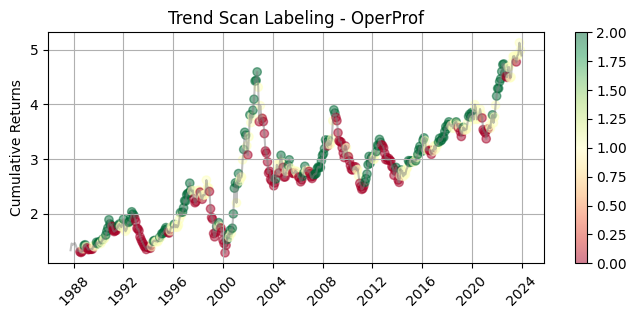

In [10]:
# visualize labels for one of the variables

plt.subplots(figsize=(8,3))
plt.plot(df1.iloc[:,4], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df1.loc[trnd_lbl_df.index, df1.columns[4]],
            c=trnd_lbl_df.iloc[:,4].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[4]}')
plt.show()

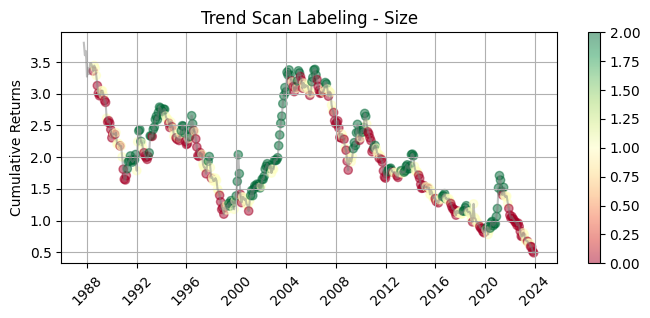

In [11]:
# visualize labels for another one of the variables

plt.subplots(figsize=(8,3))
plt.plot(df1.iloc[:,5], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df1.loc[trnd_lbl_df.index, df1.columns[5]],
            c=trnd_lbl_df.iloc[:,5].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[5]}')
plt.show()

In [12]:
# concatenate regime labels from EDA back
trnd_lbl_df1 = pd.concat([trnd_lbl_df, df1['regime']], axis=1, join='inner')
trnd_lbl_df1

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size,SP500,RSSL2K,USDIDX,TBLL13WK,GDP,UNRATE,INFLATION,POLICY,GLDRSRV,CRUDOIL,regime
1988-06-30,2.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1988-07-31,2.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0
1988-08-31,2.0,1.0,0.0,2.0,0.0,1.0,0.0,1.0,2.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0
1988-09-30,2.0,2.0,0.0,2.0,1.0,1.0,0.0,1.0,2.0,2.0,1.0,1.0,2.0,0.0,2.0,0.0,0.0
1988-10-31,1.0,2.0,0.0,2.0,2.0,0.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-31,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,2.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0
2023-08-31,0.0,0.0,2.0,0.0,1.0,0.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0
2023-09-30,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
2023-10-31,1.0,2.0,2.0,2.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,0.0,1.0,0.0


In [13]:
trnd_lbl_df1.to_csv('../outputs/dynotears/data_trend_labeled_dynotears_poc.csv')

csv_path = "../outputs/dynotears/data_trend_labeled_dynotears_poc.csv"
if os.path.exists(csv_path):
    trnd_lbl_df = pd.read_csv(csv_path)
else:
    url = "https://raw.githubusercontent.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/main/outputs/dynotears/data_trend_labeled_dynotears_poc.csv"
    trnd_lbl_df = pd.read_csv(url)

# convert index to datetime format
trnd_lbl_df['Unnamed: 0'] = pd.to_datetime(trnd_lbl_df['Unnamed: 0'], format='%Y-%m-%d')
trnd_lbl_df.index = trnd_lbl_df['Unnamed: 0']
trnd_lbl_df.index.name = None
del trnd_lbl_df['Unnamed: 0']
trnd_lbl_df.head()

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size,SP500,RSSL2K,USDIDX,TBLL13WK,GDP,UNRATE,INFLATION,POLICY,GLDRSRV,CRUDOIL,regime
1988-06-30,2.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1988-07-31,2.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0
1988-08-31,2.0,1.0,0.0,2.0,0.0,1.0,0.0,1.0,2.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0
1988-09-30,2.0,2.0,0.0,2.0,1.0,1.0,0.0,1.0,2.0,2.0,1.0,1.0,2.0,0.0,2.0,0.0,0.0
1988-10-31,1.0,2.0,0.0,2.0,2.0,0.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,0.0,1.0,0.0,1.0


### 1.4. Train-Test Dataset Split

In [14]:
# split data into training & testing sets
splt = 0.8

train_data = trnd_lbl_df.iloc[: int(trnd_lbl_df.shape[0] * splt)]
test_data = trnd_lbl_df.iloc[int(splt * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])]

print("Training Set Size: ", train_data.shape)
print("Start of Training Period: ", train_data.index[0])
print("End of Training Period: ", train_data.index[-1])

print("\nTesting Set Size: ", test_data.shape)
print("Start of Testing Period: ", test_data.index[0])
print("End of Testing Period: ", test_data.index[-1])

Training Set Size:  (340, 17)
Start of Training Period:  1988-06-30 00:00:00
End of Training Period:  2016-09-30 00:00:00

Testing Set Size:  (86, 17)
Start of Testing Period:  2016-10-31 00:00:00
End of Testing Period:  2023-11-30 00:00:00


## Section 2 - Dynamic Bayesian Network

In [15]:
# Functions for DYNOTEARS model
# Structure & parameter learning, model evaluation & inference

from causalnex.structure.dynotears import from_pandas_dynamic
from causalnex.network import BayesianNetwork
from causalnex.evaluation import classification_report
from causalnex.inference import InferenceEngine
from typing import Tuple
import networkx as nx
from pprint import pprint

def index_to_integers(
        data: pd.DataFrame
        ) -> pd.DataFrame:
    
    '''
    For STRUCTURE LEARNING
    Change datetime index into integers
    This is a requirement from CausalNex

    ARGS:
    data (pd.DataFrame): pandas dataframe w/ datetime index

    RETURNS:
    pd.DataFrame: pandas dataframe w/ integer index
    '''

    rst_indx_df = data.copy().reset_index(drop=True)

    return rst_indx_df

def lag_data_generate(
        data: pd.DataFrame,
        lagN: int
        ) -> pd.DataFrame:
    
    '''
    For PARAMETER LEARNING
    to generate lagged data columns required to fit CPTs

    ARGS:
    data (pd.DataFrame): pandas dataframe
    lagN (int): number of lag periods

    RETURNS:
    pd.DataFrame: pandas dataframe containing lagged data
    Note: column names will be: x_lag0, x_lag1, ..., x_lagN for e/a feature x
    '''
    
    lag_df = data.copy()
    lag_df.columns = [f'{i}_lag0' for i in data.columns]

    for i in range(1,lagN+1):
        for j in lag_df.columns:
            lag_df[f'{j[:-1]}{i}'] = lag_df[j].shift(i).fillna(0)

    return lag_df

def dyntoears_structure_learn(
        data: pd.DataFrame,
        lagN: int,
        lambd_w: float = 0.1,
        lambd_a: float = 0.1,
        w_thresh: float = 0.05,
        ) -> nx.DiGraph:
    
    '''
    Learn the dynamic Bayesian network structure based on DYNOTEARS model

    ARGS:
    data (pd.DataFrame): pandas dataframe
    lagN (int): number of lag periods
    lambd_w (float): parameter for l1 regularisation of intra-slice edges
    lambd_a (float): parameter for l1 regularisation of inter-slice edges
    w_thresh (float): fixed threshold for absolute edge weights
    
    For more information on other DYNOTEARS model args, please refer to:
    https://github.com/mckinsey/causalnex/blob/develop/causalnex/structure/dynotears.py

    RETURNS:
    nx.DiGraph: a NetworkX DiGraph object (representing the DBN structure)
    '''

    int_idx_df = index_to_integers(data)

    causal_graph = from_pandas_dynamic(
        int_idx_df,
        lagN,
        lambda_w = lambd_w,
        lambda_a = lambd_a,
        w_threshold = w_thresh,
    )

    return causal_graph

def dynotears_parameter_learn(
        causal_graph: nx.DiGraph,
        data: pd.DataFrame,
        lagN: int
        ) -> Tuple[BayesianNetwork, dict]:

    '''
    Calculate the network's conditional probability distributions

    ARGS:
    causal_graph (nx.DiGraph): a NetworkX DiGraph object (representing the DBN structure)
    data (pd.DataFrame): pandas dataframe
    lagN (int): number of lag periods
    
    For more information on parameter learning, please refer to:
    https://github.com/mckinsey/causalnex/blob/develop/causalnex/network/network.py

    RETURNS:
    A causalnex.network BayesianNetwork object: the parameterized DBN
    dict: dictionary containing conditional probability tables (CPTs)
    '''

    # fetch the largest DAG from structure learning
    bn = BayesianNetwork(causal_graph.get_largest_subgraph())

    # generate lagged data
    cpt_df = lag_data_generate(index_to_integers(data), lagN)

    # fit parameters to the BN
    bn = bn.fit_node_states(cpt_df)
    bn = bn.fit_cpds(cpt_df,
                    method = 'BayesianEstimator',
                    bayes_prior = 'K2')
    
    # select variables that are present as nodes in the fitted BN
    a, b = zip(*bn.edges)
    slctd_nodes = list(dict.fromkeys(list(a) + list(b)))

    # store conditional probability tables (CPTs) in a dict
    CPT = {}
    for i in slctd_nodes:
        CPT[i] = pd.DataFrame(bn.cpds[i])

    return bn, CPT

def dynotears_model_evaluation(
        bn: BayesianNetwork,
        data: pd.DataFrame,
        lagN: int
        ) -> None:

    '''
    Prints out classification reports for the nodes of interest
    (For our case, only for the 6 factors)

    PARAMETERS:
    bn (causalnex.network BayesianNetwork object): the parameterized DBN
    data (pd.DataFrame): pandas dataframe
    lagN (int): number of lag periods

    RETURNS:
    None

    '''

    test_df = lag_data_generate(index_to_integers(data), lagN)
    
    # print classification report & show ROC curves
    for c in test_df.columns[:6]:

        print(10 * '----')
        print(f'{c}\n')
        pprint(classification_report(bn, test_df, c))

def dynotears_inference(
        bn: BayesianNetwork,
        data: pd.DataFrame,
        lagN: int = 1,
        idx: int = -1,
        lag_var: str = '0',
        prnt_evdnc: bool = True,
        ) -> pd.DataFrame:

    '''
    Performs inference based on lag1 state evidence

    PARAMETERS:
    bn (causalnex.network BayesianNetwork object): the parameterized DBN
    data (pd.DataFrame): pandas dataframe
    lagN (int): number of lag periods
    idx (int): index row number (time point) taken as evidence
    lag_var (str): choice of _lag0 or _lag1 variables to serve as evidence
    prnt_evdnc (bool): if True, prints out the evidence used to make inference

    RETURNS:
    pd.DataFrame: a pandas DataFrame with marginal probabilities
    '''

    test_df = lag_data_generate(index_to_integers(data), lagN)

    # only take relevant 'from' lag0 or lag1 nodes as evidence
    a, _ = zip(*bn.edges)
    slctd_nodes = [i for i in a if i[-5:] == f'_lag{lag_var}']
    evdnc_df = test_df.loc[:,slctd_nodes]

    # make inferences based on the evidence
    ie = InferenceEngine(bn)
    mrgnls = ie.query(evdnc_df.iloc[idx,:].to_dict())
    if prnt_evdnc:
        print("Inference based on lag1 states evidence below completed:\n")
        pprint(evdnc_df.iloc[idx,:].to_dict())
    
    return pd.DataFrame(mrgnls)

### 2.1. Structure Learning

In [16]:
# structure learning
grph =  dyntoears_structure_learn(train_data, lagN=1)

# inspect the edges
for e in grph.edges:
    print(e)

('BM_lag0', 'Size_lag0')
('BM_lag1', 'BM_lag0')
('IdioVol3F_lag0', 'OperProf_lag0')
('IdioVol3F_lag0', 'INFLATION_lag0')
('IdioVol3F_lag1', 'IdioVol3F_lag0')
('Investment_lag1', 'Investment_lag0')
('Investment_lag1', 'SP500_lag0')
('Mom12m_lag0', 'IdioVol3F_lag0')
('Mom12m_lag0', 'POLICY_lag0')
('Mom12m_lag1', 'Mom12m_lag0')
('OperProf_lag1', 'IdioVol3F_lag0')
('OperProf_lag1', 'Mom12m_lag0')
('OperProf_lag1', 'OperProf_lag0')
('Size_lag0', 'RSSL2K_lag0')
('Size_lag1', 'Size_lag0')
('SP500_lag0', 'BM_lag0')
('SP500_lag0', 'RSSL2K_lag0')
('SP500_lag0', 'GDP_lag0')
('SP500_lag1', 'SP500_lag0')
('RSSL2K_lag0', 'USDIDX_lag0')
('RSSL2K_lag1', 'Mom12m_lag0')
('RSSL2K_lag1', 'Size_lag0')
('RSSL2K_lag1', 'SP500_lag0')
('RSSL2K_lag1', 'RSSL2K_lag0')
('RSSL2K_lag1', 'INFLATION_lag0')
('USDIDX_lag1', 'USDIDX_lag0')
('TBLL13WK_lag0', 'USDIDX_lag0')
('TBLL13WK_lag0', 'GDP_lag0')
('TBLL13WK_lag1', 'TBLL13WK_lag0')
('GDP_lag0', 'POLICY_lag0')
('GDP_lag1', 'Mom12m_lag0')
('GDP_lag1', 'GDP_lag0')
('UNR

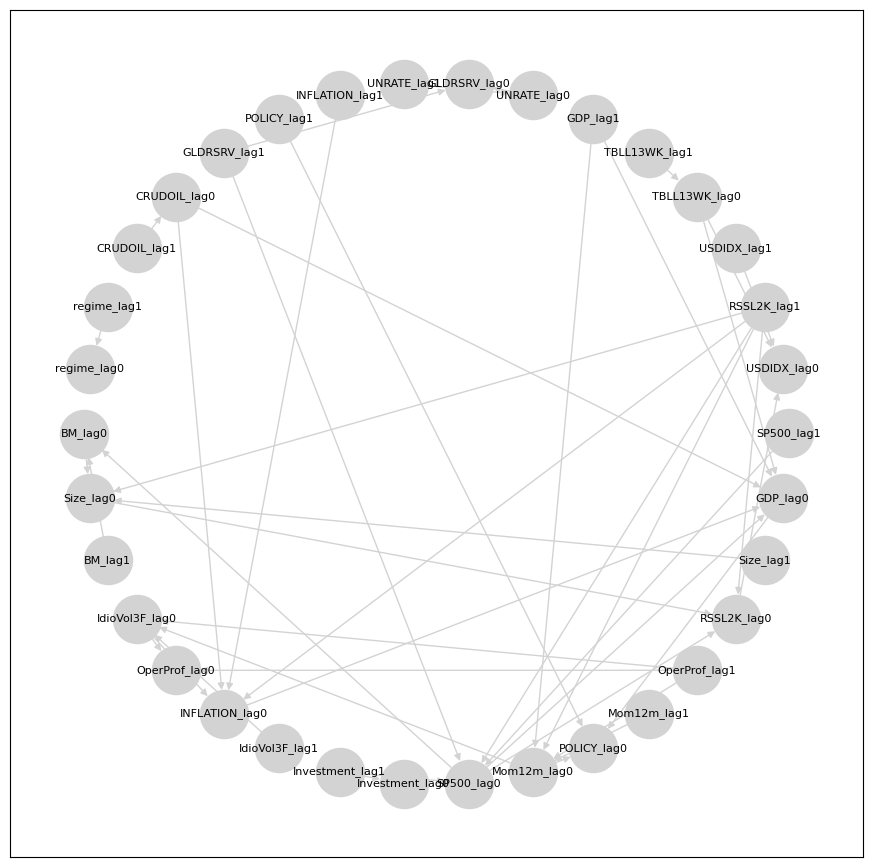

In [17]:
# visualize the estimated DAG structure
plt.subplots(figsize = (11,11))
G = nx.DiGraph()
G.add_edges_from(grph.edges)
pos = nx.shell_layout(G)
nx.draw_networkx(G, pos,
                 node_color = 'lightgrey',
                 node_size = 1200,
                 edge_color = 'lightgrey',
                 font_size = 8,
                 font_weight = 14)
plt.show()

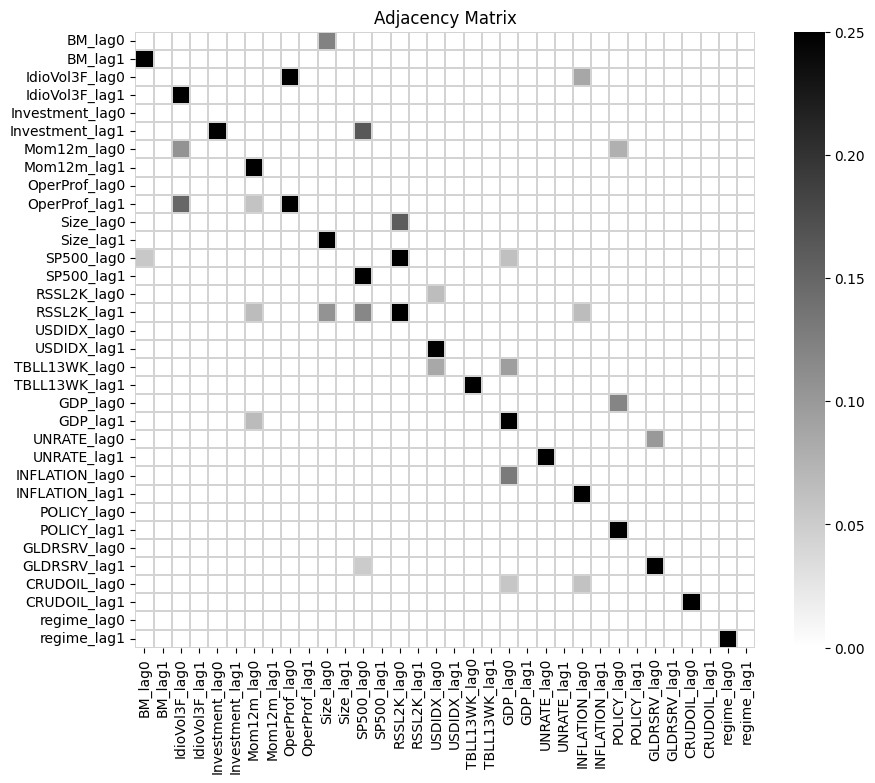

In [18]:
# visualize adjacency matrix
adj_mtx = nx.adjacency_matrix(grph)
adj_mtx_df = pd.DataFrame(data = adj_mtx.toarray(),
                          columns = grph.nodes,
                          index = grph.nodes)

plt.subplots(figsize=(10,8))
heatmap(adj_mtx_df,
        linecolor = 'lightgrey',
        linewidths = 0.01,
        vmax = 0.25, # lower the max value to observe weak links
        cmap = 'binary')
plt.title('Adjacency Matrix')
plt.show()

### 2.2. Parameter Learning

In [19]:
# parameter learning
bn, CPT = dynotears_parameter_learn(grph, train_data, lagN=1)

# show a CPT for 1 node as an example
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

CPT['Size_lag0']

BM_lag0           0.0                                                    \
RSSL2K_lag1       0.0                           1.0                       
Size_lag1         0.0       1.0       2.0       0.0       1.0       2.0   
Size_lag0                                                                 
0.0          0.703704  0.318182  0.166667  0.583333  0.277778  0.285714   
1.0          0.259259  0.636364  0.333333  0.333333  0.555556  0.285714   
2.0          0.037037  0.045455  0.500000  0.083333  0.166667  0.428571   

BM_lag0                                    1.0                           \
RSSL2K_lag1       2.0                      0.0                      1.0   
Size_lag1         0.0  1.0       2.0       0.0       1.0       2.0  0.0   
Size_lag0                                                                 
0.0          0.545455  0.4  0.210526  0.666667  0.411765  0.083333  0.4   
1.0          0.363636  0.5  0.157895  0.285714  0.470588  0.166667  0.5   
2.0          0.090909  0.1  0.631579  0.047619  0.117647  0.750000  0.1   

BM_lag0                                                   2.0            \
RSSL2K_lag1                      2.0                      0.0             
Size_lag1         1.0       2.0  0.0  1.0       2.0       0.0       1.0   
Size_lag0                                                                 
0.0          0.190476  0.133333  0.6  0.3  0.041667  0.666667  0.333333   
1.0          0.571429  0.200000  0.2  0.4  0.083333  0.250000  0.583333   
2.0          0.238095  0.666667  0.2  0.3  0.875000  0.083333  0.083333   

BM_lag0                                                                  
RSSL2K_lag1                 1.0                  2.0                     
Size_lag1         2.0       0.0       1.0   2.0  0.0       1.0      2.0  
Size_lag0                                                                
0.0          0.111111  0.470588  0.230769  0.16  0.2  0.142857  0.06250  
1.0          0.222222  0.352941  0.461538  0.08  0.6  0.428571  0.09375  
2.0          0.666667  0.176471  0.307692  0.76  0.2  0.428571  0.84375

### 2.3. Model Evaluation

In [20]:
# model evaluation
dynotears_model_evaluation(bn, test_data, lagN=1)

----------------------------------------
BM_lag0

{'BM_lag0_0.0': {'f1-score': 0.7466666666666667,
                 'precision': 0.7368421052631579,
                 'recall': 0.7567567567567568,
                 'support': 37.0},
 'BM_lag0_1.0': {'f1-score': 0.4888888888888889,
                 'precision': 0.5,
                 'recall': 0.4782608695652174,
                 'support': 23.0},
 'BM_lag0_2.0': {'f1-score': 0.6538461538461539,
                 'precision': 0.6538461538461539,
                 'recall': 0.6538461538461539,
                 'support': 26.0},
 'accuracy': 0.6511627906976745,
 'macro avg': {'f1-score': 0.6298005698005698,
               'precision': 0.6302294197031039,
               'recall': 0.6296212600560427,
               'support': 86.0},
 'weighted avg': {'f1-score': 0.6496640826873386,
                  'precision': 0.6484088127294981,
                  'recall': 0.6511627906976745,
                  'support': 86.0}}
-------------------------------

### 2.4. An Inference Example

In [21]:
# using the first lag1 data point of test data as evidence
mrgnls = dynotears_inference(bn, test_data, lagN=1, idx=0, lag_var='1')

Inference based on lag1 states evidence below completed:

{'BM_lag1': 0.0,
 'CRUDOIL_lag1': 0.0,
 'GDP_lag1': 0.0,
 'GLDRSRV_lag1': 0.0,
 'INFLATION_lag1': 0.0,
 'IdioVol3F_lag1': 0.0,
 'Investment_lag1': 0.0,
 'Mom12m_lag1': 0.0,
 'OperProf_lag1': 0.0,
 'POLICY_lag1': 0.0,
 'RSSL2K_lag1': 0.0,
 'SP500_lag1': 0.0,
 'Size_lag1': 0.0,
 'TBLL13WK_lag1': 0.0,
 'UNRATE_lag1': 0.0,
 'USDIDX_lag1': 0.0}


In [22]:
# show the marginal probabilities only for the factors

fctr = ['BM_lag0',
        'Size_lag0',
        'IdioVol3F_lag0',
        'OperProf_lag0',
        'Investment_lag0',
        'Mom12m_lag0']

mrgnls.loc[:,fctr]

,BM_lag0,Size_lag0,IdioVol3F_lag0,OperProf_lag0,Investment_lag0,Mom12m_lag0
0.0,0.745543,0.694279,0.708777,0.812762,0.745614,0.4
1.0,0.208100,0.264335,0.239267,0.113278,0.184211,0.4
2.0,0.046357,0.041385,0.051956,0.073959,0.070175,0.2


## Section 3 - Single Train-Test Split Static Backtest

### 3.1. State-Dependent Returns & Covariance Estimation

In [23]:
# calculate monthly returns
df2 = df1.copy().loc[train_data.index, df1.columns[:6]].pct_change().fillna(0)

# probability of each state
p0 = p1 = p2 = 1/3
pis = np.array([p0, p1, p2])

In [24]:
# calculate returns for e/a state (trend) for e/a factor (from training data)

def state_dpndt_returns(
        ret_df: pd.DataFrame,
        lbl_df: pd.DataFrame,
        mrgnls: pd.DataFrame
        ) -> Tuple[np.array, np.array]:

    '''
    Calculates state-dependent expected returns

    TO DO: elaborate docstrings later
    '''

    global pis

    ret_state = pd.DataFrame(index = [0, 1, 2])
    temp0 = pd.DataFrame()

    for v in df1.columns[:6]:

        temp0['ret'] = ret_df.loc[lbl_df.index,v]
        temp0['state'] = lbl_df.loc[:,v].values

        # # Optional: visualize the state-dependent return distributions
        # from seaborn import histplot
        # lbl = ['Down-Trend', 'Sideways', 'Up-Trend']
        # plt.subplots(figsize=(6,3))
        # for x in range(3):
        #     histplot(temp0['ret'].loc[temp0['state'] == x],
        #             kde=True,
        #             element='step',
        #             label=lbl[x])
        # plt.legend()
        # plt.xlabel('Monthly Returns')
        # plt.title(f'State-Dependent Return Distributions - {v}')
        # plt.show()

        temp1 = temp0.groupby('state')['ret'].agg(['mean'])
        ret_state[v] = temp1['mean']
    
    # adjust returns by marginal probabilities
    fctr_mrgnls = mrgnls.loc[:,fctr].copy()
    fctr_mrgnls.columns = [i[:-5] for i in fctr] # delete "_lag0" from names
    adj_ret_state = fctr_mrgnls * ret_state
    
    # create arrays for annualized mean returns for e/a state
    mu_0 = np.array(adj_ret_state.iloc[0,:] * 12)
    mu_1 = np.array(adj_ret_state.iloc[1,:] * 12)
    mu_2 = np.array(adj_ret_state.iloc[2,:] * 12)
    mus = [mu_0, mu_1, mu_2]

    # calculate mixture mean
    mu_bar = sum(pi * mu for pi, mu in zip(pis, mus))

    return mus, mu_bar

In [25]:
mus, mu_bar = state_dpndt_returns(df2, train_data, mrgnls)
mu_bar

array([-0.04185994, -0.06240964, -0.03197473, -0.00203465, -0.05426879,
       -0.07363325])

In [26]:
mus

[array([-0.14031655, -0.25410319, -0.11807646, -0.12770237, -0.19334772,
        -0.2183984 ]),
 array([ 0.00358374,  0.0410707 ,  0.01327574,  0.02220107,  0.00389499,
        -0.01393444]),
 array([0.01115298, 0.02580357, 0.00887653, 0.09939736, 0.02664635,
        0.01143309])]

In [27]:
# estimate state-dependent covariant matrices

def state_dpndt_covar(
        ret_df: pd.DataFrame,
        lbl_df: pd.DataFrame,
        mus: np.array,
        mu_bar: np.array
        ) -> Tuple[pd.DataFrame, pd.DataFrame]:

    '''
    Calculates state-dependent covariance

    TO DO: elaborate docstrings later
    '''
    
    global pis
    
    # starting with the first factor
    s_0 = ret_df['BM'].loc[lbl_df['BM'] == 0]
    s_1 = ret_df['BM'].loc[lbl_df['BM'] == 1]
    s_2 = ret_df['BM'].loc[lbl_df['BM'] == 2]

    # continue w/ the other factors
    # NOTE: this is a crude estimation
    # since the factors are often in different trends at any given time
    for v in ret_df.columns[1:6]:
        x = pd.concat([s_0, ret_df[v].loc[lbl_df[v] == 0]], axis=1, join='outer').fillna(0)
        s_0 = x
        y = pd.concat([s_1, ret_df[v].loc[lbl_df[v] == 1]], axis=1, join='outer').fillna(0)
        s_1 = y
        z = pd.concat([s_2, ret_df[v].loc[lbl_df[v] == 2]], axis=1, join='outer').fillna(0)
        s_2 = z

    # generate estimated annualized covariance matrices
    Sigma_0 = s_0.cov() * 12
    Sigma_1 = s_1.cov() * 12
    Sigma_2 = s_2.cov() * 12
    Sigmas = [Sigma_0, Sigma_1, Sigma_2]

    # calculate mixture covariance
    Sigma_mix = np.zeros((6, 6))
    for pi, mu, Sigma in zip(pis, mus, Sigmas):
        Sigma_mix += pi * (Sigma + np.outer(mu - mu_bar, mu - mu_bar))
    
    return Sigmas, Sigma_mix

In [28]:
Sigmas, Sigma_mix = state_dpndt_covar(df2, train_data, mus, mu_bar)

In [29]:
Sigmas[0]

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
BM,0.003166,-0.000620,0.000013,-0.001472,-0.000384,0.000436
IdioVol3F,-0.000620,0.026617,0.000095,0.009827,0.009385,-0.001522
Investment,0.000013,0.000095,0.003964,0.001409,-0.000259,0.001139
Mom12m,-0.001472,0.009827,0.001409,0.032137,0.001840,0.000440
OperProf,-0.000384,0.009385,-0.000259,0.001840,0.007321,-0.000858
Size,0.000436,-0.001522,0.001139,0.000440,-0.000858,0.007175


In [30]:
Sigma_mix

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
BM,0.008950,0.008931,0.004639,0.005470,0.006668,0.008780
IdioVol3F,0.008931,0.044589,0.008035,0.017841,0.020968,0.010982
Investment,0.004639,0.008035,0.007957,0.006626,0.005607,0.007484
Mom12m,0.005470,0.017841,0.006626,0.030140,0.010522,0.009669
OperProf,0.006668,0.020968,0.005607,0.010522,0.017645,0.008744
Size,0.008780,0.010982,0.007484,0.009669,0.008744,0.020672


### 3.2. Static Portfolio Optimization

In [31]:
import cvxpy as cp

def mean_variance_optimization(
    mu: np.array,
    Sigma: np.array,
    short_selling: bool = True,
    max_weight: float = 0.3,
    target_return: float = None
    ) -> dict:

    """
    Perform mean-variance portfolio optimization using cvxpy.

    Parameters
    ----------
    mu : np.ndarray
        Expected returns vector of shape (n_assets,).
    Sigma : np.ndarray
        Covariance matrix of shape (n_assets, n_assets).
    short_selling : bool, optional
        If False, weights are constrained to [0, max_weight].
        If True, weights are constrained to [-max_weight, +max_weight].
    max_weight : float, optional
        Maximum absolute weight allowed per asset (default 0.3 = 30%).
    target_return : float, optional
        Desired portfolio expected return. If None, maximize Sharpe ratio proxy (muᵀw / sqrt(wᵀΣw)).

    Returns
    -------
    dict
        A dictionary with optimal weights, portfolio return, and portfolio variance.
    """

    n = len(mu)
    w = cp.Variable(n)

    portfolio_return = mu @ w
    portfolio_variance = cp.quad_form(w, Sigma)

    # Constraints
    constraints = [cp.sum(w) == 1]

    if short_selling:
        constraints += [w <= max_weight, w >= -max_weight]
    else:
        constraints += [w >= 0, w <= max_weight]

    # Objective: minimize variance for a given target return, or maximize risk-adjusted return
    if target_return is not None:
        constraints += [portfolio_return >= target_return]
        objective = cp.Minimize(portfolio_variance)
    else:
        # Maximize (mu^T w) / sqrt(w^T Σ w) -> equivalent to maximize mu^T w - λ * variance
        # Approximate by maximizing risk-adjusted return: muᵀw - λ * wᵀΣw
        risk_aversion = 0.5  # tweak this parameter to control risk-return tradeoff
        objective = cp.Maximize(portfolio_return - risk_aversion * portfolio_variance)

    problem = cp.Problem(objective, constraints)
    problem.solve()

    if w.value is None:
        raise ValueError("Optimization failed. Try adjusting constraints or target return.")

    weights = np.array(w.value).flatten()
    port_return = mu @ weights
    port_var = weights.T @ Sigma @ weights

    return {
        "weights": weights,
        "expected_return": port_return,
        "variance": port_var,
        "std_dev": np.sqrt(port_var)
    }

#### 3.2.1. MVO Portfolio Optimization

In [32]:
# define annualized mean returns vector (mu) & covariance matrix (Sigma)
mu_mvo = df2.mean() * 12
Sigma_mvo = df2.cov() * 12

In [33]:
np.random.seed(6)
n_assets = 6

# MVO long-only portfolio
mvo_long_only = mean_variance_optimization(
    np.array(mu_mvo),
    np.array(Sigma_mvo),
    short_selling=False
    )

print("MVO long-only portfolio weights:\n", np.round(mvo_long_only["weights"], 3))
print("Expected return:", round(mvo_long_only["expected_return"], 4))
print("Volatility:", round(mvo_long_only["std_dev"], 4))

# MVO long-short portfolio
mvo_long_short = mean_variance_optimization(
    np.array(mu_mvo),
    np.array(Sigma_mvo),
    short_selling=True
    )

print("\nMVO long-short portfolio weights:\n", np.round(mvo_long_short["weights"], 3))
print("Expected return:", round(mvo_long_short["expected_return"], 4))
print("Volatility:", round(mvo_long_short["std_dev"], 4))

MVO long-only portfolio weights:
 [ 0.3  0.3 -0.   0.3  0.1 -0. ]
Expected return: 0.0724
Volatility: 0.1301

MVO long-short portfolio weights:
 [ 0.3  0.3  0.1  0.3  0.3 -0.3]
Expected return: 0.0872
Volatility: 0.1743


#### 3.2.2. DBN Portfolio Optimization

In [34]:
# DBN long-only portfolio
dbn_long_only = mean_variance_optimization(
    np.array(mu_bar),
    np.array(Sigma_mix),
    short_selling=False
    )

print("DBN long-only portfolio weights:\n", np.round(dbn_long_only["weights"], 3))
print("Expected return:", round(dbn_long_only["expected_return"], 4))
print("Volatility:", round(dbn_long_only["std_dev"], 4))

# DBN long-short portfolio
dbn_long_short = mean_variance_optimization(
    np.array(mu_bar),
    np.array(Sigma_mix),
    short_selling=True
    )

print("\nDBN long-short portfolio weights:\n", np.round(dbn_long_short["weights"], 3))
print("Expected return:", round(dbn_long_short["expected_return"], 4))
print("Volatility:", round(dbn_long_short["std_dev"], 4))

DBN long-only portfolio weights:
 [ 0.3 -0.   0.3  0.3  0.1  0. ]
Expected return: -0.0282
Volatility: 0.0938

DBN long-short portfolio weights:
 [ 0.3    0.068  0.3    0.3    0.3   -0.268]
Expected return: -0.0235
Volatility: 0.1046


In [35]:
cmpr_port = pd.DataFrame(
    data = {
        'MVO - Long Only': mvo_long_only["weights"],
        'DBN - Long Only': dbn_long_only["weights"],
        'MVO - Long-Short': mvo_long_short["weights"],
        'DBN - Long-Short': dbn_long_short["weights"],
    },
    index = [f[:-5] for f in fctr]
)
cmpr_port

,MVO - Long Only,DBN - Long Only,MVO - Long-Short,DBN - Long-Short
BM,3.000000e-01,3.000000e-01,0.3,0.30000
Size,3.000000e-01,-1.354597e-22,0.3,0.06828
IdioVol3F,-2.053258e-23,3.000000e-01,0.1,0.30000
OperProf,3.000000e-01,3.000000e-01,0.3,0.30000
Investment,1.000000e-01,1.000000e-01,0.3,0.30000
Mom12m,-4.066895e-23,4.528931e-23,-0.3,-0.26828


### 3.3. Static Backtest Results

In [36]:
# fee is assumed to be 5% per annum charged monthly
fee = 0.05 / 12

# risk-free rate assumed to be 0% for simplicity
rf = 0.0

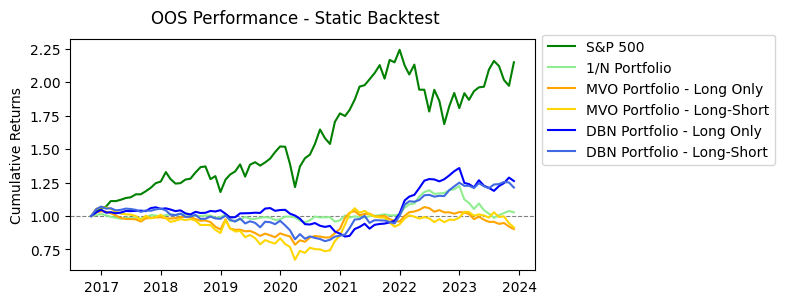

In [37]:
# calculate returns from the test dataset period (including S&P500 benchmark)
df3 = df1.copy().loc[test_data.index, df1.columns[:6]].pct_change().fillna(0)
sp500 = df1.copy().loc[test_data.index, 'SP500'].pct_change().fillna(0)

# calculate portfolio cumulative returns

# MVO portfolio
mvo_long_only_ret = cmpr_port.loc[:, 'MVO - Long Only'] * df3
mvo_long_short_ret = cmpr_port.loc[:, 'MVO - Long-Short'] * df3

# DBN portfolio
dbn_long_only_ret = cmpr_port.loc[:, 'DBN - Long Only'] * df3
dbn_long_short_ret = cmpr_port.loc[:, 'DBN - Long-Short'] * df3

# Equal-weight (1/N) portfolio
eql_wght = np.full((1,6), 1/6)
eql_port = (1 + (eql_wght * df3).sum(axis=1)).cumprod()

# plot walk-forward cumulative returns
plt.subplots()

plt.axhline(1, linewidth = 0.8, c='grey', linestyle = 'dashed')

# # No need to plot the individual factors - too busy!
# plt.plot((1 + df3).cumprod(),
#          linewidth = 0.8, alpha = 0.5, label = df3.columns)

plt.plot((1 + sp500).cumprod(), label='S&P 500', c = 'green')

plt.plot(eql_port, label = '1/N Portfolio', c = 'lightgreen')

plt.plot(
    (1 + mvo_long_only_ret.sum(axis=1)).cumprod(),
    label = 'MVO Portfolio - Long Only',
    c = 'orange'
    )

plt.plot(
    (1 + mvo_long_short_ret.sum(axis=1)).cumprod(),
    label = 'MVO Portfolio - Long-Short',
    c = 'gold'
    )

plt.plot(
    (1 + dbn_long_only_ret.sum(axis=1)).cumprod(),
    label = 'DBN Portfolio - Long Only',
    c = 'blue'
    )

plt.plot(
    (1 + dbn_long_short_ret.sum(axis=1)).cumprod(),
    label = 'DBN Portfolio - Long-Short',
    c = 'royalblue'
    )

plt.ylabel('Cumulative Returns')
plt.suptitle("OOS Performance - Static Backtest")
plt.legend(bbox_to_anchor = (1, 1.05))
plt.show()

In [38]:
# functions to calculate performance metrics

def drawdown(ret):

    # cum_ret: cumulative returns pandas series
    # returns drawdown series

    cumul_ret = cum_ret(ret)
    cumul_max = cumul_ret.cummax()
    drwdwn =  (cumul_ret / cumul_max) - 1

    return drwdwn

def sharpe_ratio(ret, rf):

    # ret: daily simple returns pandas series
    # rf: risk-free rate
    # returns annualized Sharpe ratio

    sharpe =  (ret.mean() - (rf/12)) / ret.std() * np.sqrt(12)

    return sharpe

def sortino_ratio(ret, rf):

    # ret: daily simple returns pandas series
    # rf: risk-free rate
    # returns annualized Sortino ratio
    
    std_ngtv = ret[ret<0].std()
    sortino =   (ret.mean() - (rf/12)) / std_ngtv * np.sqrt(12)

    return sortino

def cum_ret(ret):

    # ret: daily simple returns pandas series
    # returns cumulative returns series of a $1 investment

    cumul_ret = (1 + ret).cumprod() # - 1

    return cumul_ret

def CAGR(ret):

    # ret: daily simple returns pandas series
    # returns annualized returns (i.e. compounded annual growth rate)

    cumul_ret = cum_ret(ret)
    cagr = (cumul_ret.iloc[-1] / cumul_ret.iloc[0]) ** (1 / (len(ret) / 12)) - 1

    return cagr

def prfrmnc_mtrcs(ret):
    
    mtrcs = {
        "Cumulative Returns": cum_ret(ret).iloc[-1],
        "CAGR": CAGR(ret),
        "Volatility": ret.std(),
        "Sharpe Ratio": sharpe_ratio(ret, rf),
        "Sortino Ratio": sortino_ratio(ret, rf),
        "Max Drawdown": drawdown(ret).min()       
    }
    
    return mtrcs

In [39]:
# show a summary dataframe comparing the performance metrics

sttc_bcktst = pd.DataFrame(
    index = [
        'DBN - Long Only',
        'MVO - Long Only',
        'DBN - Long-Short',
        'MVO Long-Short',
        'Equal-Weight (1/N)',
        'S&P500'
        ],
    data = [
        prfrmnc_mtrcs(dbn_long_only_ret.sum(axis=1)),
        prfrmnc_mtrcs(mvo_long_only_ret.sum(axis=1)),
        prfrmnc_mtrcs(dbn_long_short_ret.sum(axis=1)),
        prfrmnc_mtrcs(mvo_long_short_ret.sum(axis=1)),
        prfrmnc_mtrcs((eql_wght * df3).sum(axis=1)),
        prfrmnc_mtrcs(sp500)
    ]
    ).T

sttc_bcktst

,DBN - Long Only,MVO - Long Only,DBN - Long-Short,MVO Long-Short,Equal-Weight (1/N),S&P500
Cumulative Returns,1.261304,0.902266,1.212550,0.914974,1.027274,2.148390
CAGR,0.032923,-0.014248,0.027257,-0.012323,0.003762,0.112606
Volatility,0.025108,0.025175,0.026640,0.038037,0.020022,0.047775
Sharpe Ratio,0.415640,-0.121765,0.337043,-0.029600,0.088795,0.729983
Sortino Ratio,0.657896,-0.209414,0.567905,-0.053402,0.104582,1.068202
Max Drawdown,-0.204936,-0.241406,-0.241243,-0.367648,-0.194083,-0.247695


In [40]:
sttc_bcktst.to_csv('../outputs/dynotears/static_backtest_results.csv')

## Section 4 - Walk-Forward Backtest with Re-Training

A rolling window approach starting with the first 50% of the data for training initially was adopted. The DBN model was then retrained & the portfolio was rebalanced every 12 months. For comparison, a rolling MVO portfolio optimization was performed too in an identical manner.

In [41]:
# split data into training & testing sets
splt = 0.5

train_data = trnd_lbl_df.iloc[: int(trnd_lbl_df.shape[0] * splt)]
test_data = trnd_lbl_df.iloc[int(splt * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])]

print("Training Set Size: ", train_data.shape)
print("Start of Training Period: ", train_data.index[0])
print("End of Training Period: ", train_data.index[-1])

print("\nTesting Set Size: ", test_data.shape)
print("Start of Testing Period: ", test_data.index[0])
print("End of Testing Period: ", test_data.index[-1])

Training Set Size:  (213, 17)
Start of Training Period:  1988-06-30 00:00:00
End of Training Period:  2006-02-28 00:00:00

Testing Set Size:  (213, 17)
Start of Testing Period:  2006-03-31 00:00:00
End of Testing Period:  2023-11-30 00:00:00


In [42]:
# re-training period every N month(s)
N = 12

# the length of training dataset
L = trnd_lbl_df.iloc[: int(trnd_lbl_df.shape[0] * splt)].shape[0]

In [43]:
# initiate arrays of NaNs to store all weights from all rounds

wghts_dbn_long_only = np.empty((trnd_lbl_df.shape[0]-L, 6))
wghts_dbn_long_short = np.empty((trnd_lbl_df.shape[0]-L, 6))
wghts_mvo_long_only = np.empty((trnd_lbl_df.shape[0]-L, 6))
wghts_mvo_long_short = np.empty((trnd_lbl_df.shape[0]-L, 6))

wghts_dbn_long_only[:] = np.nan
wghts_dbn_long_short[:] = np.nan
wghts_mvo_long_only[:] = np.nan
wghts_mvo_long_short[:] = np.nan

for t in range(L, trnd_lbl_df.shape[0]):

    # set a loop round counter for checking
    rnd = t-L
    print(f"\nLoop iteration no: {rnd}")

    # counter for wghts_..._all array
    s = int(rnd * N)
    e = int(s + N - 1)
    # print(s, e)

    #--------------------------------------------------------------
    # Step 1: Data Segmentation & Processing
    #--------------------------------------------------------------

    # # for expanding training window
    # train_data = trnd_lbl_df.iloc[:t,:].copy()

    # for rolling training window
    train_data = trnd_lbl_df.iloc[t-L:t,:].copy()

    # testing window
    test_data = trnd_lbl_df.iloc[t:t+N,:].copy()

    # calculate monthly returns data 
    ret_data = df1.copy().loc[train_data.index, df1.columns[:6]].pct_change().fillna(0)

    #--------------------------------------------------------------
    # Step 2: DBN Structure & Parameter Learning
    #--------------------------------------------------------------

    print("Performing DBN structure & parameter learning")

    # structure learning
    grph = dyntoears_structure_learn(train_data, lagN=1)

    # parameter learning
    try:
        bn, CPT = dynotears_parameter_learn(grph, train_data, lagN=1)
    
    # if the BN is not acyclic,
    except Exception as x:
        print(x)

        # first, we try going back to structure learning
        # and increase the w_threshold
        try:
            print("Performing structure learning with increased w_threshold")
            grph = dyntoears_structure_learn(train_data, lagN=1, w_thresh=0.065)
            bn, CPT = dynotears_parameter_learn(grph, train_data, lagN=1)
        
        # lastly, if that doesn't work, we'd just not allocate any weights
        # i.e. we'd go with the previous optimization results
        except Exception as x:
            print(x)
            print("Acyclicity issue unresolved, no allocation changes assigned")
            continue
    
    print("DBN structure & parameter learning completed")

    #--------------------------------------------------------------
    # Step 3: Inference & State-Dependent mu & Sigma Calculations
    #--------------------------------------------------------------

    print("Performing inferences & portfolio optimizations")

    # inference from evidence (for the last training time point)
    mrgnls = dynotears_inference(bn, test_data, lagN=1, idx=-1, lag_var='1', prnt_evdnc=False)

    # calculate state-dependent returns & covariance
    mus, mu_bar = state_dpndt_returns(ret_data, train_data, mrgnls)
    _, Sigma_mix = state_dpndt_covar(ret_data, train_data, mus, mu_bar)

    # calculate long-only & long-short factor portfolios
    
    dbn_long_only = mean_variance_optimization(
    np.array(mu_bar),
    np.array(Sigma_mix),
    short_selling=False
    )

    # DBN long-short portfolio
    dbn_long_short = mean_variance_optimization(
        np.array(mu_bar),
        np.array(Sigma_mix),
        short_selling=True
        )
    
    wghts_dbn_long_only[s:e,:] = dbn_long_only["weights"]
    wghts_dbn_long_short[s:e,:] = dbn_long_short["weights"]

    #--------------------------------------------------------------
    # Step 4: Rolling MVO for comparison
    #--------------------------------------------------------------

    # define annualized mean returns vector (mu) & covariance matrix (Sigma)
    mu_mvo = ret_data.mean() * 12
    Sigma_mvo = ret_data.cov() * 12

    # calculate long-only & long-short factor portfolios

    # MVO long-only portfolio
    mvo_long_only = mean_variance_optimization(
        np.array(mu_mvo),
        np.array(Sigma_mvo),
        short_selling=False
        )

    # MVO long-short portfolio
    mvo_long_short = mean_variance_optimization(
        np.array(mu_mvo),
        np.array(Sigma_mvo),
        short_selling=True
        )
    
    wghts_mvo_long_only[s:e,:] = mvo_long_only["weights"]
    wghts_mvo_long_short[s:e,:] = mvo_long_short["weights"]

    print("Portfolio optimizations completed")

print('\n#--------------------------------------------------------------')
print('Walk-Forward backtest completed')


Loop iteration no: 0
Performing DBN structure & parameter learning
DBN structure & parameter learning completed
Performing inferences & portfolio optimizations
Portfolio optimizations completed

Loop iteration no: 1
Performing DBN structure & parameter learning
DBN structure & parameter learning completed
Performing inferences & portfolio optimizations
Portfolio optimizations completed

Loop iteration no: 2
Performing DBN structure & parameter learning
DBN structure & parameter learning completed
Performing inferences & portfolio optimizations
Portfolio optimizations completed

Loop iteration no: 3
Performing DBN structure & parameter learning
DBN structure & parameter learning completed
Performing inferences & portfolio optimizations
Portfolio optimizations completed

Loop iteration no: 4
Performing DBN structure & parameter learning
DBN structure & parameter learning completed
Performing inferences & portfolio optimizations
Portfolio optimizations completed

Loop iteration no: 5
Per

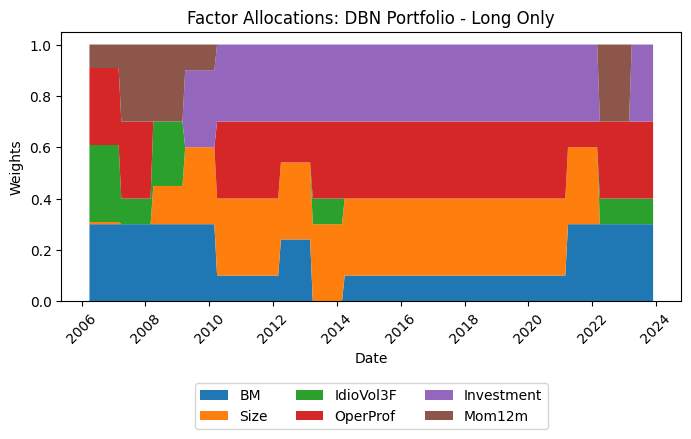

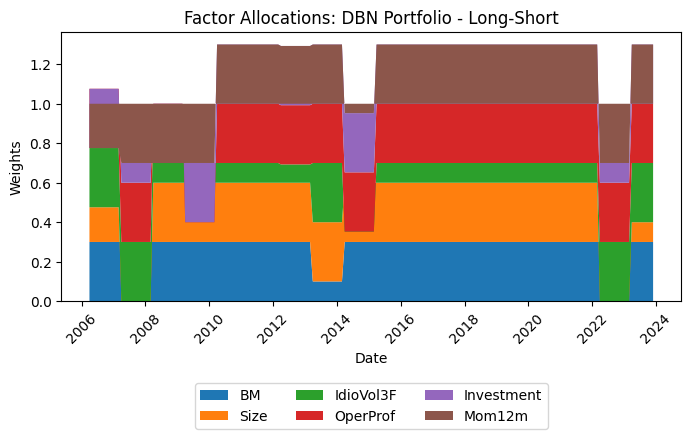

In [ ]:
dbn_portf = {
    "Long Only": wghts_dbn_long_only,
    "Long-Short": wghts_dbn_long_short
}

for p in dbn_portf:
    
    # generate a dataframe for DBN portfolio weights
    wghts_dbn = pd.DataFrame(
        columns = [i[:-5] for i in fctr],
        index = trnd_lbl_df.index[int(splt * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])],
        data = dbn_portf[p]
        )
    wghts_dbn = wghts_dbn.ffill()
    # wghts_dbn.to_csv(f'wghts_dbn_{p}.csv')
    dbn_portf[p] = wghts_dbn

    # visualize changes in weight allocations over time
    plt.subplots(figsize=(8,3.5))
    plt.stackplot(wghts_dbn.index, wghts_dbn.T)
    plt.ylabel('Weights')
    plt.xlabel('Date')
    plt.legend(wghts_dbn.columns,loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.5))
    plt.title(f'Factor Allocations: DBN Portfolio - {p}')
    plt.xticks(rotation=45)
    plt.show()

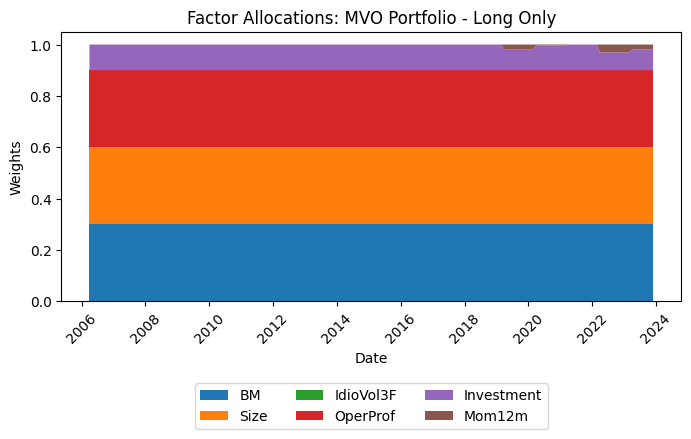

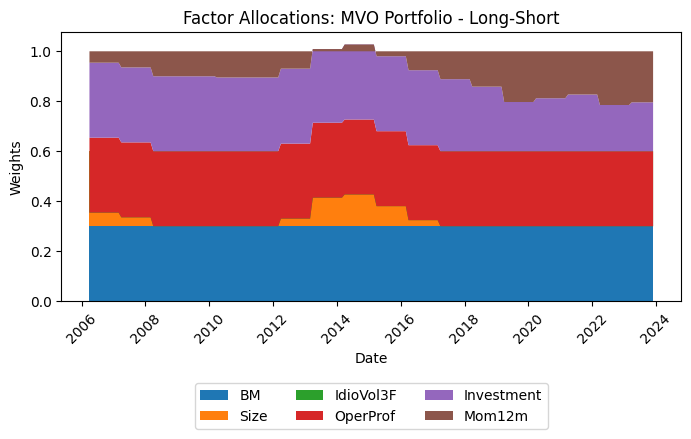

In [ ]:
mvo_portf = {
    "Long Only": wghts_mvo_long_only,
    "Long-Short": wghts_mvo_long_short
}

for p in mvo_portf:
    
    # generate a dataframe for MVO portfolio weights
    wghts_mvo = pd.DataFrame(
        columns = [i[:-5] for i in fctr],
        index = trnd_lbl_df.index[int(splt * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])],
        data = mvo_portf[p]
        )
    wghts_mvo = wghts_mvo.ffill()
    # wghts_mvo.to_csv(f'wghts_mvo_{p}.csv')
    mvo_portf[p] = wghts_mvo

    # visualize changes in weight allocations over time
    plt.subplots(figsize=(8,3.5))
    plt.stackplot(wghts_mvo.index, wghts_mvo.T)
    plt.ylabel('Weights')
    plt.xlabel('Date')
    plt.legend(wghts_mvo.columns,loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.5))
    plt.title(f'Factor Allocations: MVO Portfolio - {p}')
    plt.xticks(rotation=45)
    plt.show()

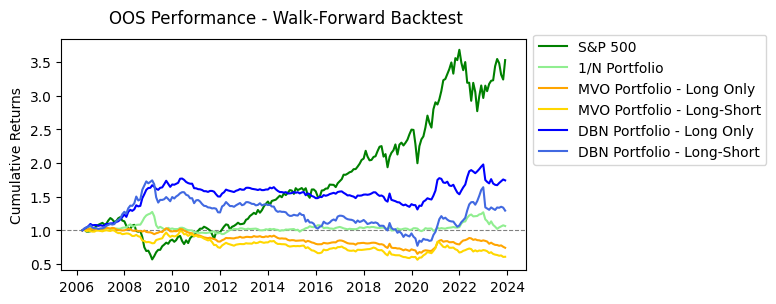

In [46]:
# calculate returns from the test dataset
df3 = df1.copy().loc[wghts_dbn.index, wghts_dbn.columns].pct_change().fillna(0)
sp500 = df1.copy().loc[wghts_dbn.index, 'SP500'].pct_change().fillna(0)

# calculate portfolio cumulative returns

# MVO portfolio
mvo_long_only_ret = mvo_portf['Long Only'] * df3
mvo_long_short_ret = mvo_portf['Long-Short'] * df3

# DBN portfolio
dbn_long_only_ret = dbn_portf['Long Only'] * df3
dbn_long_short_ret = dbn_portf['Long-Short'] * df3

# Equal-weight (1/N) portfolio
eql_wght = np.full((1,6), 1/6)
eql_port = (1 + (eql_wght * df3).sum(axis=1)).cumprod()

# plot walk-forward cumulative returns
plt.subplots()

plt.axhline(1, linewidth = 0.8, c='grey', linestyle = 'dashed')

# # No need to plot the individual factors - too busy!
# plt.plot((1 + df3).cumprod(),
#          linewidth = 0.8, alpha = 0.5, label = df3.columns)

plt.plot((1 + sp500).cumprod(), label='S&P 500', c = 'green')

plt.plot(eql_port, label = '1/N Portfolio', c = 'lightgreen')

plt.plot(
    (1 + mvo_long_only_ret.sum(axis=1)).cumprod(),
    label = 'MVO Portfolio - Long Only',
    c = 'orange'
    )

plt.plot(
    (1 + mvo_long_short_ret.sum(axis=1)).cumprod(),
    label = 'MVO Portfolio - Long-Short',
    c = 'gold'
    )

plt.plot(
    (1 + dbn_long_only_ret.sum(axis=1)).cumprod(),
    label = 'DBN Portfolio - Long Only',
    c = 'blue'
    )

plt.plot(
    (1 + dbn_long_short_ret.sum(axis=1)).cumprod(),
    label = 'DBN Portfolio - Long-Short',
    c = 'royalblue'
    )

plt.ylabel('Cumulative Returns')
plt.suptitle("OOS Performance - Walk-Forward Backtest")
plt.legend(bbox_to_anchor = (1, 1.05))
plt.show()

In [47]:
# show a summary dataframe comparing the performance metrics

wlk_fwd__bcktst = pd.DataFrame(
    index = [
        'DBN - Long Only',
        'MVO - Long Only',
        'DBN - Long-Short',
        'MVO Long-Short',
        'Equal-Weight (1/N)',
        'S&P500'
        ],
    data = [
        prfrmnc_mtrcs(dbn_long_only_ret.sum(axis=1)),
        prfrmnc_mtrcs(mvo_long_only_ret.sum(axis=1)),
        prfrmnc_mtrcs(dbn_long_short_ret.sum(axis=1)),
        prfrmnc_mtrcs(mvo_long_short_ret.sum(axis=1)),
        prfrmnc_mtrcs((eql_wght * df3).sum(axis=1)),
        prfrmnc_mtrcs(sp500)
    ]
    ).T

wlk_fwd__bcktst

,DBN - Long Only,MVO - Long Only,DBN - Long-Short,MVO Long-Short,Equal-Weight (1/N),S&P500
Cumulative Returns,1.741412,0.740417,1.292397,0.606716,1.063661,3.527613
CAGR,0.031744,-0.016789,0.014556,-0.027759,0.003483,0.073604
Volatility,0.023029,0.018547,0.035667,0.025931,0.018511,0.044985
Sharpe Ratio,0.431771,-0.231593,0.179232,-0.268855,0.086740,0.535707
Sortino Ratio,0.665772,-0.376801,0.249163,-0.454541,0.095537,0.716826
Max Drawdown,-0.259598,-0.373431,-0.557997,-0.443787,-0.259157,-0.525559


In [48]:
wlk_fwd__bcktst.to_csv('../outputs/dynotears/walk_forward_backtest_results.csv')